In [2]:
import numpy as np
import matplotlib.pyplot as plt

def euler_method(a,b,h,f,y0):
    N = int((b-a)/h)
    w = np.zeros(N+1)
    t = np.linspace(a,b,N+1)
    w[0] = y0
    for i in range(N):
        w[i+1] = w[i] + h*f(t[i],w[i])
    return w

def taylor_method_o2(a,b,h,f,df,y0):
    N = int((b-a)/h)
    w = np.zeros(N+1)
    t = np.linspace(a,b,N+1)
    w[0] = y0
    def T2(t,w):
        return f(t,w) + h*df(t,w)/2
    for i in range(N):
        w[i+1] = w[i] + h*T2(t[i],w[i])
    return w

def midpoint_method(a,b,h,f,y0):
    N = int((b-a)/h)
    w = np.zeros(N+1)
    t = np.linspace(a,b,N+1)
    w[0] = y0
    for i in range(N):
        w[i+1] = w[i] + h*f(t[i]+h/2,w[i]+h*f(t[i],w[i])/2)
    return w

def heun_method(a,b,h,f,y0):
    N = int((b-a)/h)
    w = np.zeros(N+1)
    t = np.linspace(a,b,N+1)
    w[0] = y0
    for i in range(N):
        w[i+1] = w[i] + (h/4)*(f(t[i],w[i])+3*f(t[i]+2*h/3,w[i]+(2*h/3)*f(t[i]+h/3,w[i]+(h/3)*f(t[i],w[i]))))
    return w

def rk4(a,b,h,f,y0):
    N = int((b-a)/h)
    w = np.zeros(N+1)
    t = np.linspace(a,b,N+1)
    w[0] = y0
    for i in range(N):
        K1 = h*f(t[i],w[i])
        K2 = h*f(t[i]+h/2,w[i]+K1/2)
        K3 = h*f(t[i]+h/2,w[i]+K2/2)
        K4 = h*f(t[i]+h,w[i]+K3)
        w[i+1] = w[i] + (K1+2*K2+2*K3+K4)/6
    return w

def AB4(a,b,h,f,y0):
    N = int((b-a)/h)
    w = np.zeros(N+1)
    t = np.linspace(a,b,N+1)
    w[0] = y0
    starting_values = rk4(a,b,h,f,y0)
    w[1] = starting_values[1]
    w[2] = starting_values[2]
    w[3] = starting_values[3]
    for i in range(3,N):
        w[i+1] = w[i] + h/24*(55*f(t[i],w[i])-59*f(t[i-1],w[i-1])+37*f(t[i-2],w[i-2])-9*f(t[i-3],w[i-3]))
    return w

def AM3_Prob_A(a,b,h,f,y0):
    N = int((b-a)/h)
    w = np.zeros(N+1)
    t = np.linspace(a,b,N+1)
    w[0] = y0
    starting_values = rk4(a,b,h,f,y0)
    w[1] = starting_values[1]
    w[2] = starting_values[2]
    for i in range(2,N):
        w[i+1] = 24/(24-9*h)*(w[i]+h/24*(9*(1-t[i+1]**2)+19*f(t[i],w[i])-5*f(t[i-1],w[i-1])+f(t[i-2],w[i-2])))
    return w

def AM3_Prob_B(a,b,h,f,y0):
    N = int((b-a)/h)
    w = np.zeros(N+1)
    t = np.linspace(a,b,N+1)
    w[0] = y0
    starting_values = rk4(a,b,h,f,y0)
    w[1] = starting_values[1]
    w[2] = starting_values[2]
    for i in range(2,N):
        w[i+1] = 4/(4-3*h)*(w[i]+h/24*(19*f(t[i],w[i])-5*f(t[i-1],w[i-1])+f(t[i-2],w[i-2])))
    return w

def AM3_Prob_C(a,b,h,f,y0):
    N = int((b-a)/h)
    w = np.zeros(N+1)
    t = np.linspace(a,b,N+1)
    w[0] = y0
    starting_values = rk4(a,b,h,f,y0)
    w[1] = starting_values[1]
    w[2] = starting_values[2]
    for i in range(2,N):
        w[i+1] = 4/(4-3*h*t[i+1])*(w[i]+h/24*(72*t[i+1]+19*f(t[i],w[i])-5*f(t[i-1],w[i-1])+f(t[i-2],w[i-2])))
    return w

def PC4(a,b,h,f,y0):
    N = int((b-a)/h)
    w = np.zeros(N+1)
    t = np.linspace(a,b,N+1)
    predictor = AB4(a,b,h,f,y0)
    w[0] = y0
    w[1] = predictor[1]
    w[2] = predictor[2]
    w[3] = predictor[3]
    for i in range(3,N):
        w[i+1] = w[i] + h/24*(9*f(t[i+1],predictor[i+1])+19*f(t[i],w[i])-5*f(t[i-1],w[i-1])+f(t[i-2],w[i-2]))
    return w

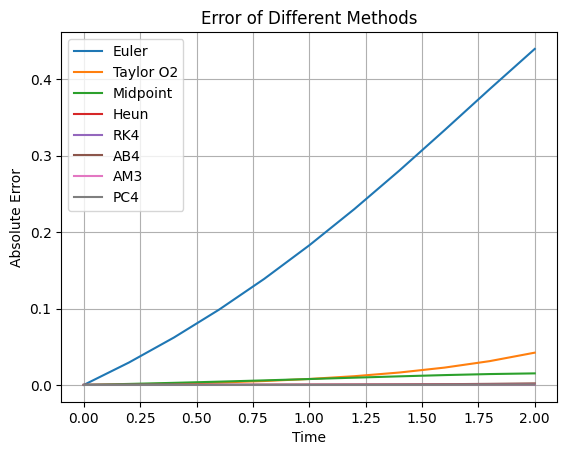

In [7]:
# Problem A, h = .2
a=0
b=2
h=.2
def fA(t,y):
    return y - t**2 +1
def dfA(t,y):
    return -2*t + y - t**2 + 1
y0 = .5
t = np.linspace(a,b,int((b-a)/h)+1)
exact = np.zeros(int((b-a)/h)+1)
for i in range(len(t)):
    exact[i] = (t[i]+1)**2-np.exp(t[i])/2
em = euler_method(a,b,h,fA,y0)
tm = taylor_method_o2(a,b,h,fA,dfA,y0)
mm = midpoint_method(a,b,h,fA,y0)
hm = heun_method(a,b,h,fA,y0)
rk = rk4(a,b,h,fA,y0)
ab = AB4(a,b,h,fA,y0)
am = AM3_Prob_A(a,b,h,fA,y0)
pc = PC4(a,b,h,fA,y0)
dfa1 = np.column_stack([t,
                        exact,
                        em,
                        abs(em - exact),
                        tm,
                        abs(tm - exact),
                        mm,
                        abs(mm - exact),
                        hm,
                        abs(hm - exact),
                        rk,
                        abs(rk - exact),
                        ab,
                        abs(ab - exact),
                        am,
                        abs(am - exact),
                        pc,
                        abs(pc - exact)])
dfa1
labels = ["Euler", "Taylor O2", "Midpoint", "Heun", "RK4", "AB4", "AM3", "PC4"]
methods = [em,tm,mm,hm,rk,ab,am,pc]
for i,j in zip(labels,methods):
    plt.plot(t,np.abs(exact-j),label=i)

plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error of Different Methods")
plt.legend()
plt.grid(True)
plt.show()

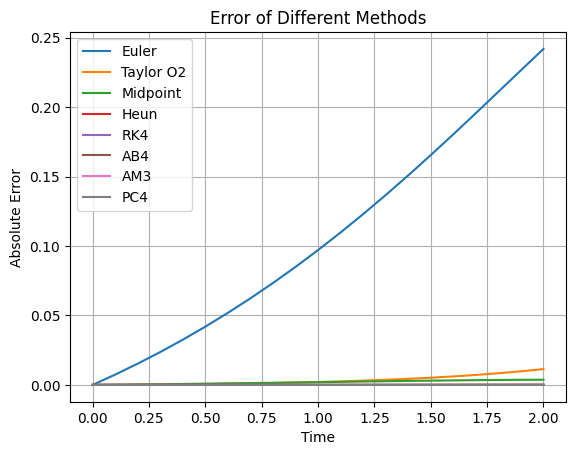

In [8]:
# Problem A, h = .1
a=0
b=2
h=.1
def fA(t,y):
    return y - t**2 +1
def dfA(t,y):
    return -2*t + y - t**2 + 1
y0 = .5
t = np.linspace(a,b,int((b-a)/h)+1)
exact = np.zeros(int((b-a)/h)+1)
for i in range(len(t)):
    exact[i] = (t[i]+1)**2-np.exp(t[i])/2
em = euler_method(a,b,h,fA,y0)
tm = taylor_method_o2(a,b,h,fA,dfA,y0)
mm = midpoint_method(a,b,h,fA,y0)
hm = heun_method(a,b,h,fA,y0)
rk = rk4(a,b,h,fA,y0)
ab = AB4(a,b,h,fA,y0)
am = AM3_Prob_A(a,b,h,fA,y0)
pc = PC4(a,b,h,fA,y0)
dfa2 = np.column_stack([t,
                        exact,
                        em,
                        abs(em - exact),
                        tm,
                        abs(tm - exact),
                        mm,
                        abs(mm - exact),
                        hm,
                        abs(hm - exact),
                        rk,
                        abs(rk - exact),
                        ab,
                        abs(ab - exact),
                        am,
                        abs(am - exact),
                        pc,
                        abs(pc - exact)])
dfa2
labels = ["Euler", "Taylor O2", "Midpoint", "Heun", "RK4", "AB4", "AM3", "PC4"]
methods = [em,tm,mm,hm,rk,ab,am,pc]
for i,j in zip(labels,methods):
    plt.plot(t,np.abs(exact-j),label=i)

plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error of Different Methods")
plt.legend()
plt.grid(True)
plt.show()

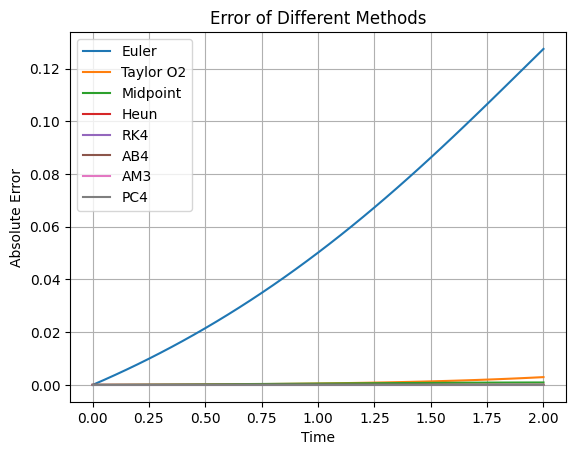

In [9]:
# Problem A, h = .05
a=0
b=2
h=.05
def fA(t,y):
    return y - t**2 +1
def dfA(t,y):
    return -2*t + y - t**2 + 1
y0 = .5
t = np.linspace(a,b,int((b-a)/h)+1)
exact = np.zeros(int((b-a)/h)+1)
for i in range(len(t)):
    exact[i] = (t[i]+1)**2-np.exp(t[i])/2
em = euler_method(a,b,h,fA,y0)
tm = taylor_method_o2(a,b,h,fA,dfA,y0)
mm = midpoint_method(a,b,h,fA,y0)
hm = heun_method(a,b,h,fA,y0)
rk = rk4(a,b,h,fA,y0)
ab = AB4(a,b,h,fA,y0)
am = AM3_Prob_A(a,b,h,fA,y0)
pc = PC4(a,b,h,fA,y0)
dfa3 = np.column_stack([t,
                        exact,
                        em,
                        abs(em - exact),
                        tm,
                        abs(tm - exact),
                        mm,
                        abs(mm - exact),
                        hm,
                        abs(hm - exact),
                        rk,
                        abs(rk - exact),
                        ab,
                        abs(ab - exact),
                        am,
                        abs(am - exact),
                        pc,
                        abs(pc - exact)])
dfa3
labels = ["Euler", "Taylor O2", "Midpoint", "Heun", "RK4", "AB4", "AM3", "PC4"]
methods = [em,tm,mm,hm,rk,ab,am,pc]
for i,j in zip(labels,methods):
    plt.plot(t,np.abs(exact-j),label=i)

plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error of Different Methods")
plt.legend()
plt.grid(True)
plt.show()

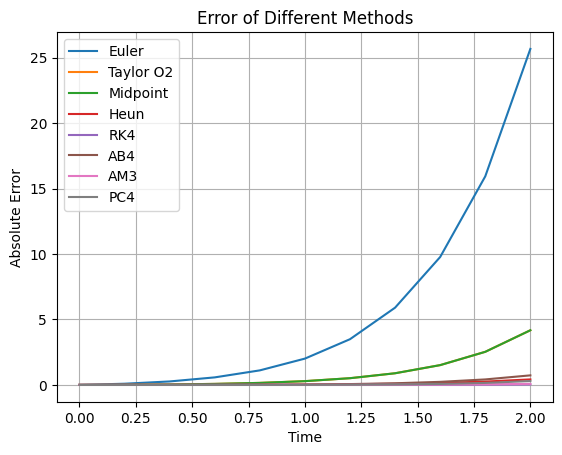

In [6]:
# Problem B, h = .2
a=0
b=2
h=.2
def fB(t,y):
    return 2*y
def dfB(t,y):
    return 4*y
y0 = 1
t = np.linspace(a,b,int((b-a)/h)+1)
exact = np.zeros(int((b-a)/h)+1)
for i in range(len(t)):
    exact[i] = np.exp(2*t[i])
em = euler_method(a,b,h,fB,y0)
tm = taylor_method_o2(a,b,h,fB,dfB,y0)
mm = midpoint_method(a,b,h,fB,y0)
hm = heun_method(a,b,h,fB,y0)
rk = rk4(a,b,h,fB,y0)
ab = AB4(a,b,h,fB,y0)
am = AM3_Prob_B(a,b,h,fB,y0)
pc = PC4(a,b,h,fB,y0)
dfb1 = np.column_stack([t,
                        exact,
                        em,
                        abs(em - exact),
                        tm,
                        abs(tm - exact),
                        mm,
                        abs(mm - exact),
                        hm,
                        abs(hm - exact),
                        rk,
                        abs(rk - exact),
                        ab,
                        abs(ab - exact),
                        am,
                        abs(am - exact),
                        pc,
                        abs(pc - exact)])
dfb1
labels = ["Euler", "Taylor O2", "Midpoint", "Heun", "RK4", "AB4", "AM3", "PC4"]
methods = [em,tm,mm,hm,rk,ab,am,pc]
for i,j in zip(labels,methods):
    plt.plot(t,np.abs(exact-j),label=i)

plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error of Different Methods")
plt.legend()
plt.grid(True)
plt.show()

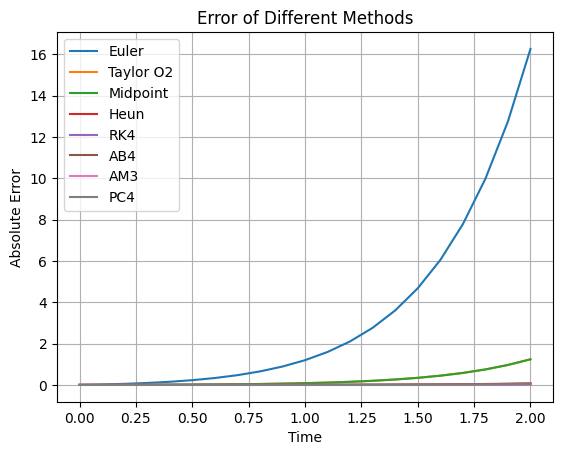

In [9]:
# Problem B, h = .1
a=0
b=2
h=.1
def fB(t,y):
    return 2*y
def dfB(t,y):
    return 4*y
y0 = 1
t = np.linspace(a,b,int((b-a)/h)+1)
exact = np.zeros(int((b-a)/h)+1)
for i in range(len(t)):
    exact[i] = np.exp(2*t[i])
em = euler_method(a,b,h,fB,y0)
tm = taylor_method_o2(a,b,h,fB,dfB,y0)
mm = midpoint_method(a,b,h,fB,y0)
hm = heun_method(a,b,h,fB,y0)
rk = rk4(a,b,h,fB,y0)
ab = AB4(a,b,h,fB,y0)
am = AM3_Prob_B(a,b,h,fB,y0)
pc = PC4(a,b,h,fB,y0)
dfb2 = np.column_stack([t,
                        exact,
                        em,
                        abs(em - exact),
                        tm,
                        abs(tm - exact),
                        mm,
                        abs(mm - exact),
                        hm,
                        abs(hm - exact),
                        rk,
                        abs(rk - exact),
                        ab,
                        abs(ab - exact),
                        am,
                        abs(am - exact),
                        pc,
                        abs(pc - exact)])
dfb2
labels = ["Euler", "Taylor O2", "Midpoint", "Heun", "RK4", "AB4", "AM3", "PC4"]
methods = [em,tm,mm,hm,rk,ab,am,pc]
for i,j in zip(labels,methods):
    plt.plot(t,np.abs(exact-j),label=i)

plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error of Different Methods")
plt.legend()
plt.grid(True)
plt.show()

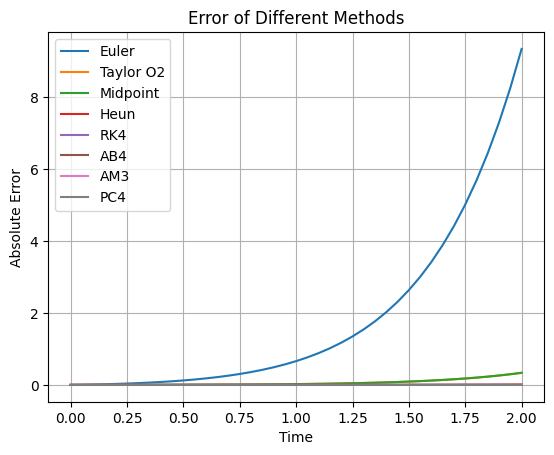

In [11]:
# Problem B, h = .05
a=0
b=2
h=.05
def fB(t,y):
    return 2*y
def dfB(t,y):
    return 4*y
y0 = 1
t = np.linspace(a,b,int((b-a)/h)+1)
exact = np.zeros(int((b-a)/h)+1)
for i in range(len(t)):
    exact[i] = np.exp(2*t[i])
em = euler_method(a,b,h,fB,y0)
tm = taylor_method_o2(a,b,h,fB,dfB,y0)
mm = midpoint_method(a,b,h,fB,y0)
hm = heun_method(a,b,h,fB,y0)
rk = rk4(a,b,h,fB,y0)
ab = AB4(a,b,h,fB,y0)
am = AM3_Prob_B(a,b,h,fB,y0)
pc = PC4(a,b,h,fB,y0)
dfb3 = np.column_stack([t,
                        exact,
                        em,
                        abs(em - exact),
                        tm,
                        abs(tm - exact),
                        mm,
                        abs(mm - exact),
                        hm,
                        abs(hm - exact),
                        rk,
                        abs(rk - exact),
                        ab,
                        abs(ab - exact),
                        am,
                        abs(am - exact),
                        pc,
                        abs(pc - exact)])
dfb3
labels = ["Euler", "Taylor O2", "Midpoint", "Heun", "RK4", "AB4", "AM3", "PC4"]
methods = [em,tm,mm,hm,rk,ab,am,pc]
for i,j in zip(labels,methods):
    plt.plot(t,np.abs(exact-j),label=i)

plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error of Different Methods")
plt.legend()
plt.grid(True)
plt.show()

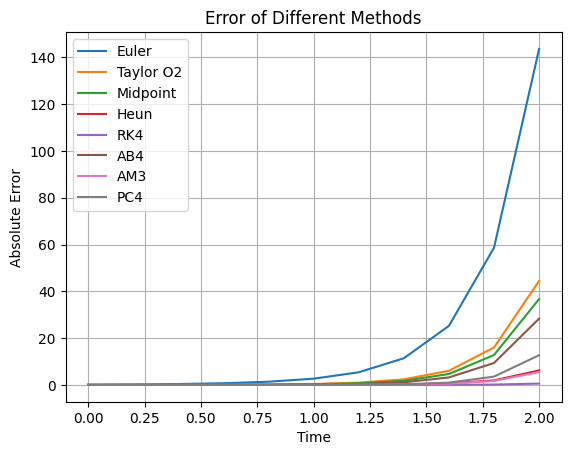

In [5]:
# Problem C,h=.2
a=0
b=2
h=.2
def fC(t,y):
    return 2*y*t + 8*t
def dfC(t,y):
    return 4*y*(t**2) + 16*(t**2) + 2*y + 8
y0 = 0
t = np.linspace(a,b,int((b-a)/h)+1)
exact = np.zeros(int((b-a)/h)+1)
for i in range(len(t)):
    exact[i] = 4*np.exp(t[i]**2) - 4
em = euler_method(a,b,h,fC,y0)
tm = taylor_method_o2(a,b,h,fC,dfC,y0)
mm = midpoint_method(a,b,h,fC,y0)
hm = heun_method(a,b,h,fC,y0)
rk = rk4(a,b,h,fC,y0)
ab = AB4(a,b,h,fC,y0)
am = AM3_Prob_C(a,b,h,fC,y0)
pc = PC4(a,b,h,fC,y0)
dfc1 = np.column_stack([t,
                        exact,
                        em,
                        abs(em - exact),
                        tm,
                        abs(tm - exact),
                        mm,
                        abs(mm - exact),
                        hm,
                        abs(hm - exact),
                        rk,
                        abs(rk - exact),
                        ab,
                        abs(ab - exact),
                        am,
                        abs(am - exact),
                        pc,
                        abs(pc - exact)])
dfc1
labels = ["Euler", "Taylor O2", "Midpoint", "Heun", "RK4", "AB4", "AM3", "PC4"]
methods = [em,tm,mm,hm,rk,ab,am,pc]
for i,j in zip(labels,methods):
    plt.plot(t,np.abs(exact-j),label=i)

plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error of Different Methods")
plt.legend()
plt.grid(True)
plt.show()

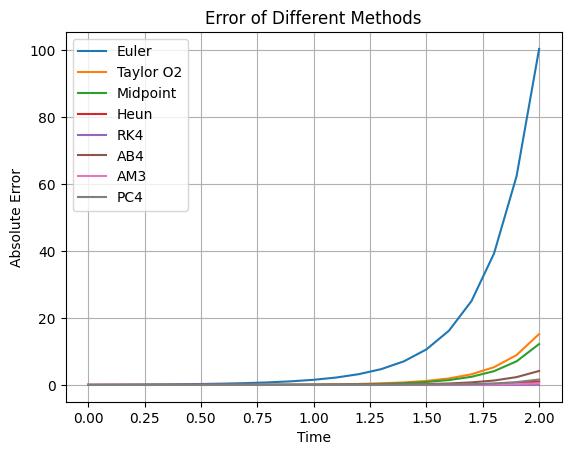

In [7]:
# Problem C,h=.1
a=0
b=2
h=.1
def fC(t,y):
    return 2*y*t + 8*t
def dfC(t,y):
    return 4*y*(t**2) + 16*(t**2) + 2*y + 8
y0 = 0
t = np.linspace(a,b,int((b-a)/h)+1)
exact = np.zeros(int((b-a)/h)+1)
for i in range(len(t)):
    exact[i] = 4*np.exp(t[i]**2) - 4
em = euler_method(a,b,h,fC,y0)
tm = taylor_method_o2(a,b,h,fC,dfC,y0)
mm = midpoint_method(a,b,h,fC,y0)
hm = heun_method(a,b,h,fC,y0)
rk = rk4(a,b,h,fC,y0)
ab = AB4(a,b,h,fC,y0)
am = AM3_Prob_C(a,b,h,fC,y0)
pc = PC4(a,b,h,fC,y0)
dfc1 = np.column_stack([t,
                        exact,
                        em,
                        abs(em - exact),
                        tm,
                        abs(tm - exact),
                        mm,
                        abs(mm - exact),
                        hm,
                        abs(hm - exact),
                        rk,
                        abs(rk - exact),
                        ab,
                        abs(ab - exact),
                        am,
                        abs(am - exact),
                        pc,
                        abs(pc - exact)])
dfc1
labels = ["Euler", "Taylor O2", "Midpoint", "Heun", "RK4", "AB4", "AM3", "PC4"]
methods = [em,tm,mm,hm,rk,ab,am,pc]
for i,j in zip(labels,methods):
    plt.plot(t,np.abs(exact-j),label=i)

plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error of Different Methods")
plt.legend()
plt.grid(True)
plt.show()

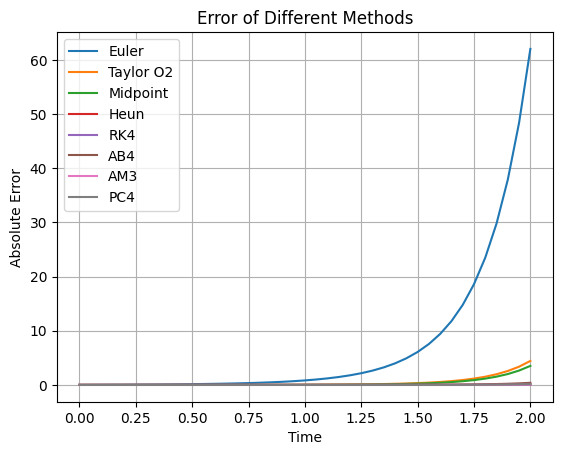

In [9]:
# Problem C,h=.1
a=0
b=2
h=.05
def fC(t,y):
    return 2*y*t + 8*t
def dfC(t,y):
    return 4*y*(t**2) + 16*(t**2) + 2*y + 8
y0 = 0
t = np.linspace(a,b,int((b-a)/h)+1)
exact = np.zeros(int((b-a)/h)+1)
for i in range(len(t)):
    exact[i] = 4*np.exp(t[i]**2) - 4
em = euler_method(a,b,h,fC,y0)
tm = taylor_method_o2(a,b,h,fC,dfC,y0)
mm = midpoint_method(a,b,h,fC,y0)
hm = heun_method(a,b,h,fC,y0)
rk = rk4(a,b,h,fC,y0)
ab = AB4(a,b,h,fC,y0)
am = AM3_Prob_C(a,b,h,fC,y0)
pc = PC4(a,b,h,fC,y0)
dfc1 = np.column_stack([t,
                        exact,
                        em,
                        abs(em - exact),
                        tm,
                        abs(tm - exact),
                        mm,
                        abs(mm - exact),
                        hm,
                        abs(hm - exact),
                        rk,
                        abs(rk - exact),
                        ab,
                        abs(ab - exact),
                        am,
                        abs(am - exact),
                        pc,
                        abs(pc - exact)])
dfc1
labels = ["Euler", "Taylor O2", "Midpoint", "Heun", "RK4", "AB4", "AM3", "PC4"]
methods = [em,tm,mm,hm,rk,ab,am,pc]
for i,j in zip(labels,methods):
    plt.plot(t,np.abs(exact-j),label=i)

plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error of Different Methods")
plt.legend()
plt.grid(True)
plt.show()